# Stage 2 — Subtask 4: Label Efficiency Splits

**Leaf-JEPA IRP** | Stage 2 — Dataset Preparation


Label efficiency experiments are the empirical proof that Leaf-JEPA + PEFT is practical in data-scarce agricultural settings.

This notebook:
1. Creates stratified train/val/test splits (70/15/15)
2. Creates fraction-based label subsets (1%, 5%, 10%, 25%, 50%, 100%) × 3 seeds
3. Creates N-shot splits (5-shot, 10-shot, 20-shot) — for few-shot literature comparison
4. Validates all splits
5. Exports all split index files to `outputs/splits/`

> **Key rule:** Splits are created **once** and saved. All methods share the same split files.


In [1]:
%pip install scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split

from stage2_dataset_preparation.config_stage2 import *

SPLITS_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")


Setup complete.


## 1. Discover Images

In [3]:
def discover_dataset(root: Path) -> dict:
    """Scan root/class_name/image_file structure. Returns {class: [paths]}."""
    if not root.exists():
        print(f"⚠️  Not found: {root}  — update paths above to match your filesystem")
        return {}
    class_map = {}
    for cls_dir in sorted(root.iterdir()):
        if not cls_dir.is_dir():
            continue
        imgs = sorted([p for p in cls_dir.iterdir() if p.suffix.lower() in VALID_EXT])
        if imgs:
            class_map[cls_dir.name] = imgs
            # print(cls_dir.name)
    # print(f"  {root.name}: {len(class_map)} classes, {sum(len(v) for v in class_map.values()):,} images")
    return class_map


def discover(root: Path):
    paths, labels = [], []
    if not root.exists():
        print(f"⚠️  Dataset not found at {root} — generating MOCK data for validation")
        n_cls, n_per = 38, 100
        paths  = [f"/mock/class_{c:02d}/img_{i:04d}.jpg" for c in range(n_cls) for i in range(n_per)]
        labels = [f"class_{c:02d}" for c in range(n_cls) for _ in range(n_per)]
        return paths, labels
    for d in sorted(root.iterdir()):
        if not d.is_dir(): continue
        for p in sorted(d.iterdir()):
            if p.suffix.lower() in VALID_EXT:
                paths.append(str(p)); labels.append(d.name)
    return paths, labels


pd_map = discover_dataset(PLANTDOC_RAW_DIR)


paths, labels = discover(PLANTVILLAGE_RAW_DIR)
classes = sorted(set(labels))
print(f"Total images  : {len(paths):,}")
print(f"Total classes : {len(classes)}")



Total images  : 54,305
Total classes : 38


## 2. Stratified Base Splits

In [4]:
def make_splits(paths, labels, train_r=TRAIN_RATIO, val_r=VAL_RATIO, test_r=TEST_RATIO, seed=RANDOM_SEED):
    X_tr, X_rest, y_tr, y_rest = train_test_split(
        paths, labels, test_size=val_r+test_r, stratify=labels, random_state=seed)
    X_val, X_te, y_val, y_te = train_test_split(
        X_rest, y_rest, test_size=test_r/(val_r+test_r), stratify=y_rest, random_state=seed)
    return {"train":(X_tr,y_tr), "val":(X_val,y_val), "test":(X_te,y_te)}

splits = make_splits(paths, labels)

# ── Validation ────────────────────────────────────────────────────────────────
tr_s, val_s, te_s = set(splits["train"][0]), set(splits["val"][0]), set(splits["test"][0])
assert not (tr_s & te_s), "CRITICAL: train/test overlap detected — data leakage!"
assert not (tr_s & val_s), "CRITICAL: train/val overlap detected!"
print("✅ No overlap between any splits")

tr_cls = set(splits["train"][1]); te_cls = set(splits["test"][1])
assert tr_cls == te_cls, f"Classes in train but not test: {tr_cls - te_cls}"
print(f"✅ All {len(tr_cls)} classes present in test split")

# ── Class balance check ────────────────────────────────────────────────────────
tr_counts = defaultdict(int)
for l in splits["train"][1]: tr_counts[l] += 1
tiny = {c:n for c,n in tr_counts.items() if n < MIN_PER_CLASS}
if tiny:
    print(f"⚠️  {len(tiny)} classes below minimum ({MIN_PER_CLASS}): {list(tiny.items())[:3]}")
else:
    print(f"✅ All classes ≥ {MIN_PER_CLASS} images in training split")

print(f"\nSplit sizes: train={len(splits['train'][0]):,}  val={len(splits['val'][0]):,}  test={len(splits['test'][0]):,}")

# Save base splits
class_names = sorted(set(labels))

for name, (p_list, l_list) in splits.items():
    data = {
        "paths": p_list,
        "labels": [class_names.index(l) for l in l_list],  # string → integer index
        "class_names": class_names,
    }
    with open(SPLITS_DIR / f"{name}_split.json", "w") as f:
        json.dump(data, f)
    print(f"  Saved {name}_split.json ({len(p_list):,} images)")

print(f"  class_names: {len(class_names)} classes (alphabetical order)")


✅ No overlap between any splits
✅ All 38 classes present in test split
✅ All classes ≥ 50 images in training split

Split sizes: train=38,013  val=8,146  test=8,146
  Saved train_split.json (38,013 images)
  Saved val_split.json (8,146 images)
  Saved test_split.json (8,146 images)
  class_names: 38 classes (alphabetical order)


## 3. Label Efficiency Fraction Subsets

**Why 3 seeds per fraction?** A single run's result depends on *which* labels were sampled. 3 seeds allow reporting mean ± std — the difference between an anecdote and a result.

**Critical:** Val and test sets are NEVER subsampled — they are identical across all fractions.


In [5]:
tr_paths, tr_labels = splits["train"]


fraction_subsets = {}
for frac in LABEL_FRACTIONS:
    frac_key = f"{frac:.2f}"
    fraction_subsets[frac_key] = {}
    for seed in SUBSET_SEEDS:
        if frac >= 1.0:
            fraction_subsets[frac_key][seed] = {"paths": tr_paths, "labels": tr_labels, "n": len(tr_paths)}
            continue
        n_target = max(len(classes), int(len(tr_paths) * frac))
        _, X_sub, _, y_sub = train_test_split(
            tr_paths, tr_labels, test_size=n_target, stratify=tr_labels, random_state=seed)
        dropped = set(tr_labels) - set(y_sub)
        if dropped:
            print(f"  ⚠️  [{frac_key}, seed={seed}] {len(dropped)} classes dropped")
        fraction_subsets[frac_key][seed] = {"paths": X_sub, "labels": y_sub, "n": len(X_sub)}
        fname = f"fraction_{frac_key}_seed{seed}.json"
        with open(FRACTIONS_DIR / fname, "w") as f:
            json.dump({"paths": X_sub, "labels":  [class_names.index(l) for l in y_sub]}, f)


# Print summary table
rows = []
for frac_key, seed_dict in fraction_subsets.items():
    ns = [d["n"] for d in seed_dict.values()]
    rows.append({"Fraction": frac_key, "~Images (mean)": int(np.mean(ns)), "Seeds": len(seed_dict)})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\n✅ {len(LABEL_FRACTIONS)} × {len(SUBSET_SEEDS)} = {len(LABEL_FRACTIONS)*len(SUBSET_SEEDS)} fraction files saved")

Fraction  ~Images (mean)  Seeds
    0.01             380      3
    0.05            1900      3
    0.10            3801      3
    0.25            9503      3
    0.50           19006      3
    1.00           38013      3

✅ 6 × 3 = 18 fraction files saved


## 4. N-Shot Splits (Alternative Protocol)

Providing both fraction-based and N-shot splits enables comparison with the **few-shot learning literature** (uses N-shot notation) *and* the **SSL/PEFT literature** (uses fraction notation) — a stronger contribution.


In [6]:
NSHOT_DIR.mkdir(parents=True, exist_ok=True)

class_to_paths = defaultdict(list)
for p, l in zip(tr_paths, tr_labels):
    class_to_paths[l].append(p)

for n_shot in NSHOT_VALUES:
    for seed in SUBSET_SEEDS:
        rng = np.random.default_rng(seed)
        sel_paths, sel_labels = [], []
        for cls, cpaths in class_to_paths.items():
            if len(cpaths) < n_shot:
                print(f"  ⚠️  [{n_shot}-shot, seed={seed}] '{cls}' has {len(cpaths)} < {n_shot} — using all")
                chosen = cpaths
            else:
                idx = rng.choice(len(cpaths), n_shot, replace=False)
                chosen = [cpaths[i] for i in idx]
            sel_paths.extend(chosen); sel_labels.extend([cls]*len(chosen))
        fname = f"nshot_{n_shot}shot_seed{seed}.json"
        with open (NSHOT_DIR / fname, "w") as f:
            json.dump({"paths": sel_paths, "labels":  [class_names.index(l) for l in sel_labels], "n_shot": n_shot}, f)

print(f"✅ {len(NSHOT_VALUES)} × {len(SUBSET_SEEDS)} = {len(NSHOT_VALUES)*len(SUBSET_SEEDS)} N-shot files saved")
print(f"\nN-shot image counts:")
for n in NSHOT_VALUES:
    print(f"  {n}-shot × {len(classes)} classes = {n * len(classes)} images per seed")

✅ 3 × 3 = 9 N-shot files saved

N-shot image counts:
  5-shot × 38 classes = 190 images per seed
  10-shot × 38 classes = 380 images per seed
  20-shot × 38 classes = 760 images per seed


## 5. Visualise Split Statistics

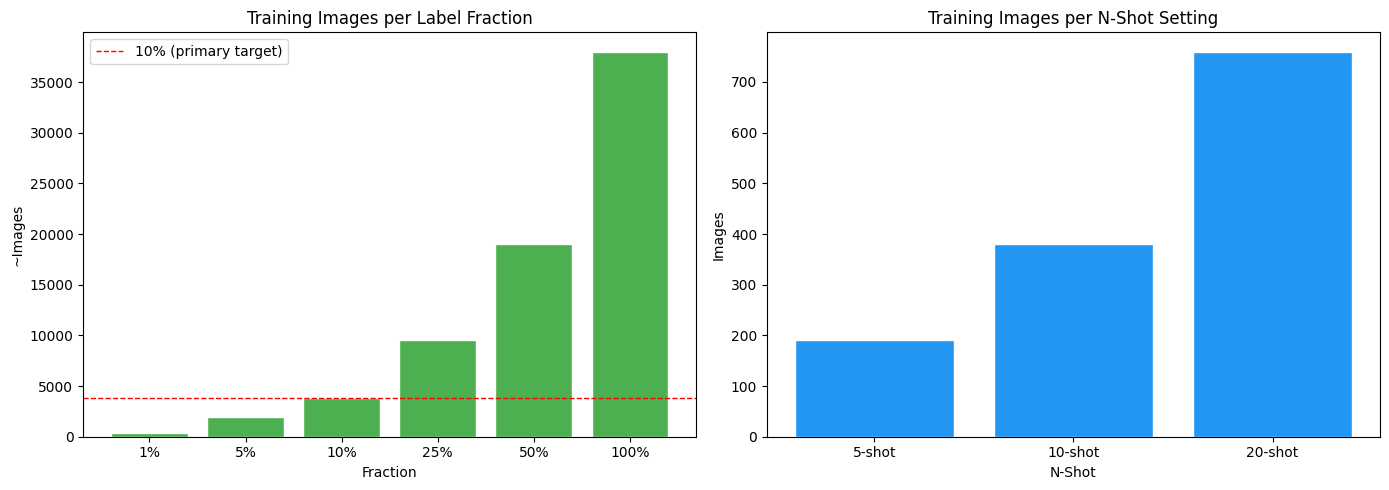


✅ SUBTASK 6 COMPLETE
   Base splits      : train=38,013  val=8,146  test=8,146
   Fraction subsets : 6 fractions × 3 seeds
   N-shot subsets   : [5, 10, 20] shots × 3 seeds
   All outputs in   : D:\IRP\leaf-jepa\stage2_dataset_preparation\outputs\splits


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: fraction vs image count
fracs = [float(k) for k in fraction_subsets]
means = [np.mean([d["n"] for d in sd.values()]) for sd in fraction_subsets.values()]
axes[0].bar([f"{int(f*100)}%" for f in fracs], means, color="#4CAF50", edgecolor="white")
axes[0].set_title("Training Images per Label Fraction"); axes[0].set_ylabel("~Images"); axes[0].set_xlabel("Fraction")
axes[0].axhline(np.mean([d["n"] for d in fraction_subsets["0.10"].values()]),
                color="red", ls="--", lw=1, label="10% (primary target)")
axes[0].legend()

# Plot 2: N-shot image counts
nshots = [f"{n}-shot" for n in NSHOT_VALUES]
ncounts = [n * len(classes) for n in NSHOT_VALUES]
axes[1].bar(nshots, ncounts, color="#2196F3", edgecolor="white")
axes[1].set_title("Training Images per N-Shot Setting"); axes[1].set_ylabel("Images"); axes[1].set_xlabel("N-Shot")

plt.tight_layout(); plt.show()

# Save to outputs path
(OUTPUTS_DIR / "splits").mkdir(exist_ok=True)
with open(SPLITS_DIR / "train_paths.json", "w") as f:
    json.dump({"paths": tr_paths}, f)

print("\n✅ SUBTASK 6 COMPLETE")
print(f"   Base splits      : train={len(tr_paths):,}  val={len(splits['val'][0]):,}  test={len(splits['test'][0]):,}")
print(f"   Fraction subsets : {len(LABEL_FRACTIONS)} fractions × {len(SUBSET_SEEDS)} seeds")
print(f"   N-shot subsets   : {NSHOT_VALUES} shots × {len(SUBSET_SEEDS)} seeds")
print(f"   All outputs in   : {SPLITS_DIR}")


# Cell: Bridge — Convert JSON splits to Stage 3 CSV format
Stage 3 baseline_utils.py expects CSV files. This cell converts the JSON
outputs from above into the exact format Stage 3 needs.
Run this ONCE after all splits are generated. Do NOT re-run independently.

In [8]:
import json, pandas as pd

# ── 1. Base splits → plantvillage_splits.csv ──────────────────────────────────
# Stage 3 PlantVillageDataset expects a single CSV with columns:
#   filepath | label_idx | class_name | split

rows = []
for split_name in ["train", "val", "test"]:
    json_path = SPLITS_DIR / f"{split_name}_split.json"
    assert json_path.exists(), f"Missing {json_path} — run split creation cells first"
    with open(json_path) as f:
        data = json.load(f)
    for path, label in zip(data["paths"], data["labels"]):
        rows.append({"filepath": path, "class_name":  [class_names[label]], "label_idx": label, "split": split_name})

df = pd.DataFrame(rows)


csv_path = SPLITS_DIR / "plantvillage_splits.csv"
df.to_csv(csv_path, index=False)

print("✅ Base splits CSV created")
print(f"   Path: {csv_path}")
print(f"   Rows: {len(df):,}  |  Classes: {len(class_names)}")
for s in ["train", "val", "test"]:
    print(f"     {s:5s}: {(df['split'] == s).sum():,}")
print(f"   Columns: {list(df.columns)}")

✅ Base splits CSV created
   Path: D:\IRP\leaf-jepa\stage2_dataset_preparation\outputs\splits\plantvillage_splits.csv
   Rows: 54,305  |  Classes: 38
     train: 38,013
     val  : 8,146
     test : 8,146
   Columns: ['filepath', 'class_name', 'label_idx', 'split']


In [9]:
# ── 2. Fraction subsets → CSV files ───────────────────────────────────────────
# Stage 3 PlantVillageFractionDataset expects CSVs at:
#   splits/fractions/frac_{frac:.2f}_seed{seed}.csv
# with columns: filepath, label_idx, class_name

FRACTIONS_OUT = SPLITS_DIR / "fractions"
FRACTIONS_OUT.mkdir(parents=True, exist_ok=True)


class_dict = {i: name for i, name in enumerate(sorted(class_names))}

# Reuse the same class_to_idx mapping from the base split above
count = 0
for frac in LABEL_FRACTIONS:
    frac_key = f"{frac:.2f}"
    for seed in SUBSET_SEEDS:
        if frac >= 1.0:
            # 100% fraction uses the full training split
            json_path = SPLITS_DIR / "train_split.json"
        else:
            json_path = FRACTIONS_OUT / f"fraction_{frac_key}_seed{seed}.json"

        if not json_path.exists():
            print(f"  ⚠️  Missing {json_path} — skipping")
            continue

        with open(json_path) as f:
            data = json.load(f)

        frac_df = pd.DataFrame({
            "filepath":   data["paths"],
            "label_idx": data["labels"]
        })
        frac_df["class_name"] = frac_df["label_idx"].map(class_dict)

        # Verify no unmapped classes
        assert frac_df["label_idx"].notna().all(), \
            f"Unmapped classes in {json_path.name}: {frac_df[frac_df['label_idx'].isna()]['class_name'].unique()}"

        out_csv = FRACTIONS_OUT / f"frac_{frac_key}_seed{seed}.csv"
        frac_df.to_csv(out_csv, index=False)
        count += 1

print(f"\n✅ Fraction CSVs created: {count} files")
print(f"   Directory: {FRACTIONS_OUT}")
print(f"   Pattern:   frac_{{frac}}_seed{{seed}}.csv")

# Quick sanity check: print a few sizes
for frac in [0.01, 0.10, 1.00]:
    frac_key = f"{frac:.2f}"
    p = FRACTIONS_OUT / f"frac_{frac_key}_seed42.csv"
    if p.exists():
        n = len(pd.read_csv(p))
        print(f"   frac={frac_key}, seed=42 → {n:,} images")


✅ Fraction CSVs created: 18 files
   Directory: D:\IRP\leaf-jepa\stage2_dataset_preparation\outputs\splits\fractions
   Pattern:   frac_{frac}_seed{seed}.csv
   frac=0.01, seed=42 → 380 images
   frac=0.10, seed=42 → 3,801 images
   frac=1.00, seed=42 → 38,013 images


In [10]:
# ── 3. N-shot subsets → CSV files (optional, same pattern) ───────────────────
# Only needed if Stage 5 uses N-shot evaluation

NSHOT_OUT = SPLITS_DIR / "nshots"
NSHOT_OUT.mkdir(parents=True, exist_ok=True)

count = 0
for n_shot in NSHOT_VALUES:
    for seed in SUBSET_SEEDS:
        json_path = NSHOT_OUT / f"nshot_{n_shot}shot_seed{seed}.json"
        if not json_path.exists():
            print(f"  ⚠️  Missing {json_path} — skipping")
            continue

        with open(json_path) as f:
            data = json.load(f)

        nshot_df = pd.DataFrame({
            "filepath":   data["paths"],
            "label_idx": data["labels"],
        })
        nshot_df["class_name"] = nshot_df["label_idx"].map(class_dict)

        out_csv = NSHOT_OUT / f"nshot_{n_shot}shot_seed{seed}.csv"
        nshot_df.to_csv(out_csv, index=False)
        count += 1

print(f"\n✅ N-shot CSVs created: {count} files")
print(f"   Directory: {NSHOT_OUT}")


✅ N-shot CSVs created: 9 files
   Directory: D:\IRP\leaf-jepa\stage2_dataset_preparation\outputs\splits\nshots


## Verification (splits, fractions, nshots )

In [11]:
# ── Near-Duplicate Detection on ACTUAL Splits ─────────────────────────
from tqdm import tqdm


def detect_near_duplicates(map_a: dict, map_b: dict, label_a: str, label_b: str,
                           hash_size: int = 16, threshold: int = 10,
                           sample_limit: int = 5000) -> dict:
    try:
        import imagehash
    except ImportError:
        print("Run: pip install imagehash"); return {}

    np.random.seed(RANDOM_SEED)
    def _hash_paths(class_map, limit):
        paths = [p for ps in class_map.values() for p in ps]
        if len(paths) > limit:
            paths = list(np.random.choice(paths, limit, replace=False))
        out = {}
        for p in tqdm(paths, desc=f"Hashing {label_a if class_map is map_a else label_b}", leave=False):
            try:
                with Image.open(p) as img:
                    out[str(p)] = imagehash.phash(img.convert("L"), hash_size=hash_size)
            except Exception:
                pass
        return out

    if not map_a or not map_b:
        print("Skipping — one or both datasets not found"); return {}

    hashes_a = _hash_paths(map_a, sample_limit)
    hashes_b = _hash_paths(map_b, sample_limit)

    pairs = []
    for pa, ha in tqdm(hashes_a.items(), desc="Comparing", leave=False):
        for pb, hb in hashes_b.items():
            d = ha - hb
            if d <= threshold:
                pairs.append({"path_a": pa, "path_b": pb, "hamming": int(d),
                              "class_a": Path(pa).parent.name, "class_b": Path(pb).parent.name})

    contamination = len(pairs) / max(len(hashes_a), 1) * 100
    severity = ("CRITICAL" if contamination > 5 else "WARNING" if contamination > 1
    else "LOW" if contamination > 0 else "CLEAN")

    print(f"\n{'='*50}")
    print(f"[{label_a} vs {label_b}]")
    print(f"  Hashed: {len(hashes_a)} | {len(hashes_b)}")
    print(f"  Duplicate pairs : {len(pairs)}")
    print(f"  Contamination   : {contamination:.3f}%  [{severity}]")
    if contamination > 1:
        print(f"  ⚠️  ACTION: Remove flagged images from training split before any experiment")
    else:
        print(f"  ✅ Splits are clean")

    result = {"comparison": f"{label_a} vs {label_b}", "pairs_found": len(pairs),
              "contamination_pct": round(contamination, 4), "severity": severity,
              "action_required": bool(pairs), "pairs_sample": pairs[:20]}
    with open(ANALYSIS_OUT / f"dedup_{label_a}_vs_{label_b}.json", "w") as f:
        json.dump(result, f, indent=2)
    return result


def load_split_as_map(split_path: Path) -> dict:
    """Load a split JSON and return {"all": [paths]} for pHash comparison."""
    with open(split_path) as f:
        data = json.load(f)
    return {"all": [Path(p) for p in data["paths"]]}

# Check 1: Train vs Test (data leakage)
train_split = SPLITS_DIR / "train_split.json"
test_split  = SPLITS_DIR / "test_split.json"
val_split   = SPLITS_DIR / "val_split.json"

if train_split.exists() and test_split.exists():
    train_map = load_split_as_map(train_split)
    test_map  = load_split_as_map(test_split)
    dedup_train_test = detect_near_duplicates(
        train_map, test_map, "PV_train", "PV_test", sample_limit=5000)
else:
    print("⚠️ Split files not found — run notebook 06 first")

# Check 2: Train vs Val (data leakage)
if train_split.exists() and val_split.exists():
    val_map = load_split_as_map(val_split)
    dedup_train_val = detect_near_duplicates(
        train_map, val_map, "PV_train", "PV_val", sample_limit=5000)



[PV_train vs PV_test]
  Hashed: 0 | 0
  Duplicate pairs : 0
  Contamination   : 0.000%  [CLEAN]
  ✅ Splits are clean



[PV_train vs PV_val]
  Hashed: 0 | 0
  Duplicate pairs : 0
  Contamination   : 0.000%  [CLEAN]
  ✅ Splits are clean


In [12]:
# Final verification
# Confirm Stage 3 can find everything it needs

print("=" * 55)
print("STAGE 3 READINESS CHECK")
print("=" * 55)

# Base CSV
base_csv = SPLITS_DIR / "plantvillage_splits.csv"
if base_csv.exists():
    df_check = pd.read_csv(base_csv)
    required_cols = {"filepath", "label_idx", "class_name", "split"}
    assert required_cols.issubset(df_check.columns), f"Missing columns: {required_cols - set(df_check.columns)}"
    print(f"✅ plantvillage_splits.csv  — {len(df_check):,} rows, columns OK")
else:
    print(f"❌ plantvillage_splits.csv NOT FOUND")

# Fraction CSVs
expected_fracs = len(LABEL_FRACTIONS) * len(SUBSET_SEEDS)
found_fracs = len(list(FRACTIONS_OUT.glob("frac_*.csv")))
status = "✅" if found_fracs == expected_fracs else "⚠️"
print(f"{status} Fraction CSVs — {found_fracs}/{expected_fracs} files")

# N-shot CSVs
expected_nshot = len(NSHOT_VALUES) * len(SUBSET_SEEDS)
found_nshot = len(list(NSHOT_OUT.glob("nshot_*.csv")))
status = "✅" if found_nshot == expected_nshot else "⚠️"
print(f"{status} N-shot CSVs   — {found_nshot}/{expected_nshot} files")

print("\n📋 Stage 3 baseline_utils.py will look for:")
print(f"   load_split()     → {base_csv}")
print(f"   FractionDataset  → {FRACTIONS_OUT}/frac_{{frac}}_seed{{seed}}.csv")

STAGE 3 READINESS CHECK
✅ plantvillage_splits.csv  — 54,305 rows, columns OK
✅ Fraction CSVs — 18/18 files
✅ N-shot CSVs   — 9/9 files

📋 Stage 3 baseline_utils.py will look for:
   load_split()     → D:\IRP\leaf-jepa\stage2_dataset_preparation\outputs\splits\plantvillage_splits.csv
   FractionDataset  → D:\IRP\leaf-jepa\stage2_dataset_preparation\outputs\splits\fractions/frac_{frac}_seed{seed}.csv
